# Task 1: Sentiment Analysis on Product Reviews
Sentiment analysis (Positive / Negative) on the IMDb Dataset: text cleaning, TF-IDF vectorization, training Logistic Regression and Naive Bayes, and visualizing the most frequent words per class.

## 1. Importing Libraries


In [66]:
# Core libraries
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# NLP
import nltk
from nltk.corpus import stopwords

# ML
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## 2. NLTK Stopwords

In [67]:
# Download the English stopwords list (only needs to run once per environment)
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## 3. Load Dataset



In [68]:
df = pd.read_csv('IMDB_Dataset.csv')

## 4. Explore Dataset

In [69]:
# Quick sanity checks: shape, missing values, and label balance
print("Dataset Shape:", df.shape)
print("Missing Values:")
print(df.isnull().sum())

Dataset Shape: (50000, 2)
Missing Values:
review       0
sentiment    0
dtype: int64


In [70]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [72]:
df['sentiment'].value_counts()  # check class balance (should be ~50/50)

,count
sentiment,
positive,25000
negative,25000


## 5. Encode Target Label

In [73]:
# Convert text labels to binary numeric labels: positive -> 1, negative -> 0
df['sentiment'] = df['sentiment'].map({
    'positive': 1,
    'negative': 0
})

In [74]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


## 6. Clean & Preprocess Text


In [75]:
def clean_text(text):
    text = text.lower()                          # normalize case
    text = re.sub(r'<.*?>', '', text)             # remove HTML tags (e.g. <br />)
    text = re.sub(r'[^a-zA-Z\s]', '', text)        # keep letters and spaces only
    words = text.split()
    words = [word for word in words if word not in stop_words]  # remove stopwords
    return ' '.join(words)

In [76]:
df['clean_review'] = df['review'].apply(clean_text)  # apply cleaning to every review

In [77]:
# Compare a raw review with its cleaned version
print("Before:")
print(df['review'].iloc[0])

print("\nAfter:")
print(df['clean_review'].iloc[0])

Before:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to

## 7. Train / Test Split

In [78]:
X = df['clean_review']
y = df['sentiment']

# 80/20 split, stratified so both sets keep the same class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## 8. TF-IDF Vectorization

In [79]:
# Convert cleaned text into TF-IDF numeric features
vectorizer = TfidfVectorizer(max_features=50000)

X_train_tfidf = vectorizer.fit_transform(X_train)  # fit + transform on train
X_test_tfidf = vectorizer.transform(X_test)         # transform only on test (no leakage)

print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(40000, 50000)
(10000, 50000)


## 9. Train Logistic Regression Classifier

In [80]:
logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [81]:
y_pred = logistic_model.predict(X_test_tfidf)

## 10. Evaluate Logistic Regression

In [82]:
accuracy = accuracy_score(y_test, y_pred)
print("Logistic Regression Accuracy:", accuracy)

Logistic Regression Accuracy: 0.8947


In [83]:
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

              precision    recall  f1-score   support

    Negative       0.90      0.89      0.89      5000
    Positive       0.89      0.90      0.90      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



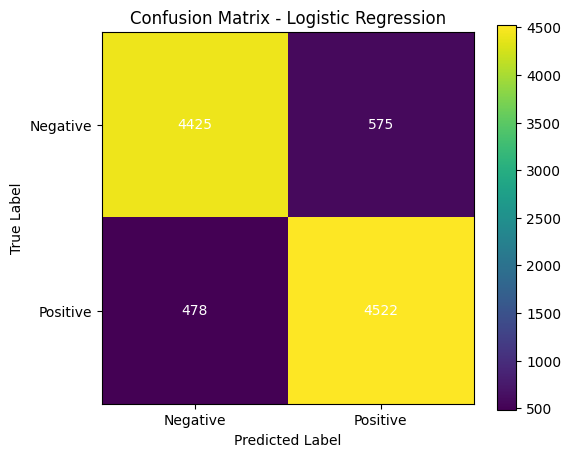

In [84]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm)

plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.colorbar()
plt.xticks([0, 1], ['Negative', 'Positive'])
plt.yticks([0, 1], ['Negative', 'Positive'])

# annotate each cell with its count
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='white')

plt.show()

## 11. Bonus: Naive Bayes Classifier & Accuracy Comparison

In [85]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

MultinomialNB()

In [86]:
nb_pred = nb_model.predict(X_test_tfidf)

In [87]:
nb_accuracy = accuracy_score(y_test, nb_pred)
print("Naive Bayes Accuracy:", nb_accuracy)
print("\nNaive Bayes Classification Report:")
print(classification_report(y_test, nb_pred, target_names=['Negative', 'Positive']))

Naive Bayes Accuracy: 0.8644

Naive Bayes Classification Report:
              precision    recall  f1-score   support

    Negative       0.86      0.88      0.87      5000
    Positive       0.87      0.85      0.86      5000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



In [88]:
# Side-by-side comparison of both models
print("Logistic Regression Accuracy:", accuracy)
print("Naive Bayes Accuracy:       ", nb_accuracy)

Logistic Regression Accuracy: 0.8947
Naive Bayes Accuracy:        0.8644


In [89]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes'],
    'Accuracy': [accuracy, nb_accuracy]
})

results

,Model,Accuracy
0,Logistic Regression,0.8947
1,Naive Bayes,0.8644


## 12. Bonus: Most Frequent Positive & Negative Words


In [90]:
# Concatenate all cleaned reviews per class into one big string, then count word frequencies
positive_text = ' '.join(df.loc[df['sentiment'] == 1, 'clean_review'])
negative_text = ' '.join(df.loc[df['sentiment'] == 0, 'clean_review'])

positive_counts = Counter(positive_text.split())
negative_counts = Counter(negative_text.split())

top_positive = positive_counts.most_common(20)
top_negative = negative_counts.most_common(20)

print("Most Frequent Words in Positive Reviews:")
print(top_positive)

print("\nMost Frequent Words in Negative Reviews:")
print(top_negative)

Most Frequent Words in Positive Reviews:
[('film', 39437), ('movie', 36043), ('one', 25739), ('like', 17057), ('good', 14352), ('great', 12647), ('story', 12381), ('see', 11869), ('time', 11786), ('well', 10980), ('really', 10676), ('also', 10553), ('would', 10368), ('even', 9365), ('much', 8999), ('first', 8864), ('films', 8457), ('love', 8401), ('people', 8365), ('best', 8302)]

Most Frequent Words in Negative Reviews:
[('movie', 47535), ('film', 35077), ('one', 24653), ('like', 21777), ('even', 14920), ('good', 14150), ('bad', 14095), ('would', 13633), ('really', 12224), ('time', 11513), ('see', 10568), ('dont', 10037), ('get', 9998), ('much', 9898), ('story', 9681), ('people', 9121), ('could', 9033), ('make', 8985), ('made', 8395), ('movies', 8357)]


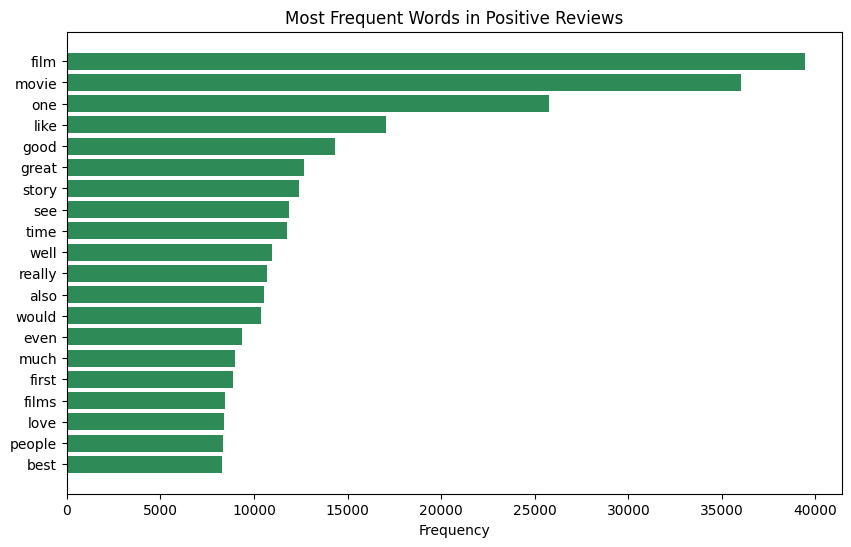

In [91]:
pos_words, pos_freqs = zip(*top_positive[::-1])  # reverse so the highest bar is on top

plt.figure(figsize=(10, 6))
plt.barh(pos_words, pos_freqs, color='seagreen')
plt.title('Most Frequent Words in Positive Reviews')
plt.xlabel('Frequency')
plt.show()

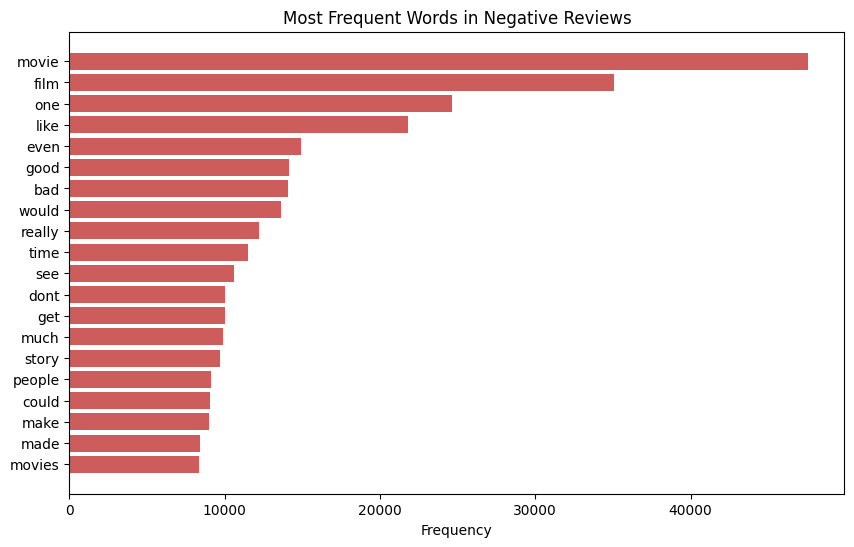

In [92]:
neg_words, neg_freqs = zip(*top_negative[::-1])

plt.figure(figsize=(10, 6))
plt.barh(neg_words, neg_freqs, color='indianred')
plt.title('Most Frequent Words in Negative Reviews')
plt.xlabel('Frequency')
plt.show()

## 13. Extra Insight (Optional): Most Influential Words per the Model


In [93]:
feature_names = np.array(vectorizer.get_feature_names_out())
coefficients = logistic_model.coef_[0]

# indices of the 20 largest (most positive) and 20 smallest (most negative) coefficients
top_positive_idx = np.argsort(coefficients)[-20:]
top_negative_idx = np.argsort(coefficients)[:20]

influential_positive_words = feature_names[top_positive_idx]
influential_negative_words = feature_names[top_negative_idx]

print("Most Influential Positive Words (model coefficients):")
print(influential_positive_words)

print("\nMost Influential Negative Words (model coefficients):")
print(influential_negative_words)

Most Influential Positive Words (model coefficients):
['well' 'today' 'fantastic' 'enjoyable' 'definitely' 'love' 'highly' 'fun'
 'superb' 'brilliant' 'enjoyed' 'favorite' 'hilarious' 'loved' 'wonderful'
 'amazing' 'best' 'perfect' 'excellent' 'great']

Most Influential Negative Words (model coefficients):
['worst' 'waste' 'awful' 'bad' 'boring' 'poor' 'terrible' 'nothing'
 'worse' 'dull' 'poorly' 'horrible' 'fails' 'instead' 'disappointing'
 'annoying' 'supposed' 'minutes' 'disappointment' 'lame']


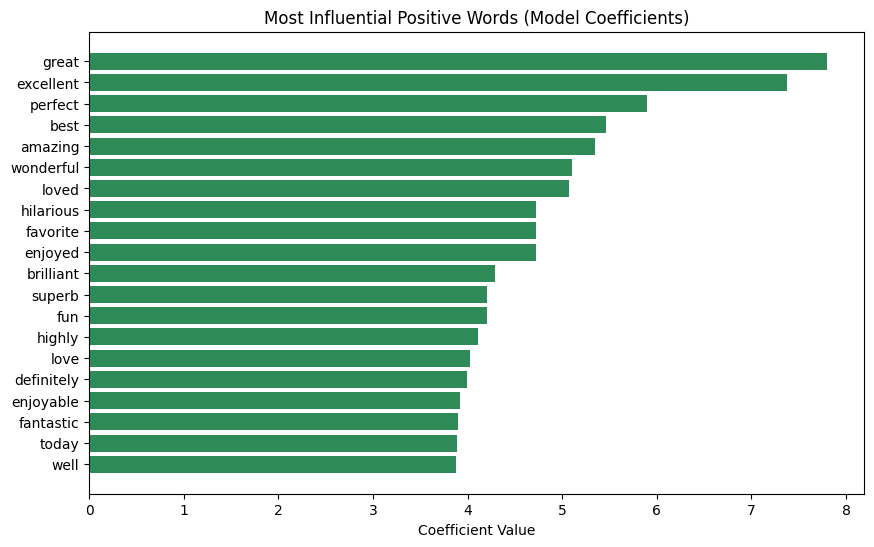

In [94]:
plt.figure(figsize=(10, 6))
plt.barh(influential_positive_words, coefficients[top_positive_idx], color='seagreen')
plt.title('Most Influential Positive Words (Model Coefficients)')
plt.xlabel('Coefficient Value')
plt.show()

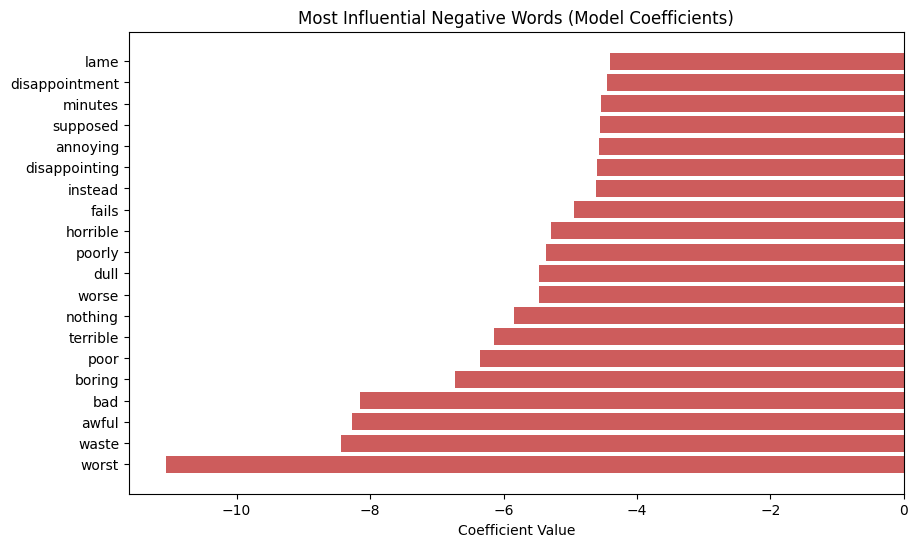

In [95]:
plt.figure(figsize=(10, 6))
plt.barh(influential_negative_words, coefficients[top_negative_idx], color='indianred')
plt.title('Most Influential Negative Words (Model Coefficients)')
plt.xlabel('Coefficient Value')
plt.show()

## 14. Test on New Reviews

In [96]:
def predict_sentiment(review_text, model=logistic_model):
    """Clean, vectorize, and classify a single raw review string."""
    cleaned = clean_text(review_text)
    vectorized = vectorizer.transform([cleaned])
    prediction = model.predict(vectorized)[0]
    return "Positive Review" if prediction == 1 else "Negative Review"

print(predict_sentiment("This product is amazing and I really love it"))
print(predict_sentiment("This product is terrible and I hate it"))

Positive Review
Negative Review
